# **Initializations**

In [1]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pyspark.sql import SparkSession
from pyspark.sql.types import *
from pyspark.sql.functions import *
from pyspark.sql.functions import col, to_date, to_timestamp, year, month, dayofmonth, \
                                  weekofyear, dayofweek, sum, countDistinct, round, lit, \
                                  when

from pyspark.ml import pipeline
from pyspark.ml.feature import VectorAssembler, StandardScaler, StringIndexer

from pyspark.ml.regression import RandomForestRegressor
from pyspark.ml.evaluation import RegressionEvaluator

from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator

In [2]:
# Initialize SparkSession
my_spark = SparkSession.builder.appName("SalesForecast").getOrCreate()
my_spark

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).


25/09/07 12:57:56 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


# **Data Ingestion and Preprocessing**

In [3]:
# Importing sales data and save it as a PySpark DataFrame
sales_data = my_spark.read.csv(
    path = "Online Retail.csv",
    header = True,
    inferSchema = True,
    sep = ","
)

sales_data.count()

384721

In [4]:
# Showing the first row of DataFrame 
sales_data.show(1, truncate=False)

+---------+---------+----------------------------------+--------+---------+----------+--------------+-------------------+----+-----+----+---+---------+
|InvoiceNo|StockCode|Description                       |Quantity|UnitPrice|CustomerID|Country       |InvoiceDate        |Year|Month|Week|Day|DayOfWeek|
+---------+---------+----------------------------------+--------+---------+----------+--------------+-------------------+----+-----+----+---+---------+
|536365   |85123A   |WHITE HANGING HEART T-LIGHT HOLDER|6       |2.55     |17850     |United Kingdom|2010-01-12 08:26:00|2010|1    |2   |12 |1        |
+---------+---------+----------------------------------+--------+---------+----------+--------------+-------------------+----+-----+----+---+---------+
only showing top 1 row



In [5]:
# Schema of DataFrame
print(sales_data.printSchema())

root
 |-- InvoiceNo: integer (nullable = true)
 |-- StockCode: string (nullable = true)
 |-- Description: string (nullable = true)
 |-- Quantity: integer (nullable = true)
 |-- UnitPrice: double (nullable = true)
 |-- CustomerID: integer (nullable = true)
 |-- Country: string (nullable = true)
 |-- InvoiceDate: timestamp (nullable = true)
 |-- Year: integer (nullable = true)
 |-- Month: integer (nullable = true)
 |-- Week: integer (nullable = true)
 |-- Day: integer (nullable = true)
 |-- DayOfWeek: integer (nullable = true)

None


In [6]:
# Check for missing/null values in the following columns
null_check_cols = ["CustomerID", "InvoiceNo", "InvoiceDate", "StockCode", "Quantity", "UnitPrice", "Country"]

sales_data.select([sum(when(col(c).isNull(),1).otherwise(0)).alias(f"null_{c}") for c in null_check_cols]) \
          .show()

+---------------+--------------+----------------+--------------+-------------+--------------+------------+
|null_CustomerID|null_InvoiceNo|null_InvoiceDate|null_StockCode|null_Quantity|null_UnitPrice|null_Country|
+---------------+--------------+----------------+--------------+-------------+--------------+------------+
|              0|             0|               0|             0|            0|             0|           0|
+---------------+--------------+----------------+--------------+-------------+--------------+------------+



# **Exploratory Data Analysis**

In [7]:
# Total number of rows in DataFrame
sales_data.count()

384721

In [8]:
# Distinct values of the following columns
sales_data.agg(*[countDistinct(col).alias(f"distinct_{col}") \
                 for col in ["InvoiceNo", "StockCode", "CustomerID", "Country"]]) \
          .show()

+------------------+------------------+-------------------+----------------+
|distinct_InvoiceNo|distinct_StockCode|distinct_CustomerID|distinct_Country|
+------------------+------------------+-------------------+----------------+
|             17635|              3649|               4261|              37|
+------------------+------------------+-------------------+----------------+



In [9]:
# Distinct values of the following columns
sales_data.agg(*[countDistinct(col).alias(f"distinct_{col}") \
                 for col in ["Year", "Month", "Week", "Day", "DayOfWeek"]]) \
          .show()

+-------------+--------------+-------------+------------+------------------+
|distinct_Year|distinct_Month|distinct_Week|distinct_Day|distinct_DayOfWeek|
+-------------+--------------+-------------+------------+------------------+
|            2|            12|           52|          31|                 7|
+-------------+--------------+-------------+------------+------------------+



In [10]:
# Numbers of distinct CustomerID per each Country
sales_data.groupby(["Country"]).agg(countDistinct("CustomerID").alias("country_customers")) \
          .sort("country_customers", ascending=False) \
          .show(37)

+--------------------+-----------------+
|             Country|country_customers|
+--------------------+-----------------+
|      United Kingdom|             3848|
|             Germany|               93|
|              France|               87|
|               Spain|               30|
|             Belgium|               25|
|         Switzerland|               21|
|            Portugal|               19|
|               Italy|               14|
|             Finland|               12|
|             Austria|               11|
|              Norway|               10|
|             Denmark|                9|
|           Australia|                9|
|     Channel Islands|                8|
|              Sweden|                8|
|         Netherlands|                8|
|              Cyprus|                8|
|               Japan|                7|
|              Poland|                6|
|         Unspecified|                4|
|                 USA|                4|
|              G

In [11]:
# Lets summarize both Quantity and UnitPrice
sales_data.select(["Quantity", "UnitPrice"]).describe().show()

+-------+-----------------+-----------------+
|summary|         Quantity|        UnitPrice|
+-------+-----------------+-----------------+
|  count|           384721|           384721|
|   mean|8.306411659358341|2.910920095342942|
| stddev| 9.30133553185389|4.187107266433108|
|    min|                1|              0.1|
|    max|               54|            649.5|
+-------+-----------------+-----------------+



In [12]:
# Group by Year, Month, Week, DayOfWeek and calculate the sum of Quantity
sales_data.groupby(["Year", "Month", "Week", "DayOfWeek"]) \
          .agg(sum("Quantity").alias("SUM_Quantity")) \
          .sort("SUM_Quantity", ascending=False) \
          .show()

+----+-----+----+---------+------------+
|Year|Month|Week|DayOfWeek|SUM_Quantity|
+----+-----+----+---------+------------+
|2011|   10|  41|        1|       25847|
|2011|    9|  38|        3|       25376|
|2011|    5|  19|        3|       25077|
|2011|   11|  46|        3|       24316|
|2011|   11|  47|        2|       23466|
|2011|    9|  39|        3|       22355|
|2011|    7|  28|        1|       21202|
|2011|    6|  23|        4|       21045|
|2011|    6|  23|        5|       20975|
|2011|   11|  47|        1|       20847|
|2011|   11|  46|        2|       20731|
|2011|    4|  15|        0|       20504|
|2011|   11|  47|        0|       19884|
|2011|    5|  19|        1|       19879|
|2011|   11|  46|        0|       19836|
|2011|    9|  36|        6|       19788|
|2011|   10|  42|        1|       19475|
|2011|    6|  23|        6|       19402|
|2011|   11|  48|        0|       19394|
|2011|   11|  48|        2|       19034|
+----+-----+----+---------+------------+
only showing top

In [13]:
# Total Quantity and total UnitPrice for each distinct CustomerID
sales_data.groupby("CustomerID") \
          .agg(sum("Quantity").alias("customer_quantity"),
               round(sum("UnitPrice"), 2).alias("customer_unitprice")) \
          .sort("customer_unitprice", ascending=False) \
          .show(5, False)

+----------+-----------------+------------------+
|CustomerID|customer_quantity|customer_unitprice|
+----------+-----------------+------------------+
|14096     |15759            |21405.05          |
|17841     |21554            |19828.21          |
|14911     |62993            |18509.95          |
|12748     |18809            |10843.24          |
|14606     |5575             |7559.6            |
+----------+-----------------+------------------+
only showing top 5 rows



In [14]:
# Earliest and most recent purchase dates made by a customer
sales_data.agg(
    min("InvoiceDate").alias("earliest_purchase"),
    max("InvoiceDate").alias("most_recent_purchase")
).show()

+-------------------+--------------------+
|  earliest_purchase|most_recent_purchase|
+-------------------+--------------------+
|2010-01-12 08:26:00| 2011-12-10 17:19:00|
+-------------------+--------------------+



In [15]:
# Create InvoiceDate_Clean column as date from InvoiceDate as timestamp
sales_data = sales_data.withColumn("InvoiceDate_Clean", col("InvoiceDate").cast("date"))
sales_data.select(["InvoiceDate", "InvoiceDate_Clean"]).show(5, truncate=False)

+-------------------+-----------------+
|InvoiceDate        |InvoiceDate_Clean|
+-------------------+-----------------+
|2010-01-12 08:26:00|2010-01-12       |
|2010-01-12 08:26:00|2010-01-12       |
|2010-01-12 08:26:00|2010-01-12       |
|2010-01-12 08:26:00|2010-01-12       |
|2010-01-12 08:26:00|2010-01-12       |
+-------------------+-----------------+
only showing top 5 rows



In [16]:
sales_data.printSchema()

root
 |-- InvoiceNo: integer (nullable = true)
 |-- StockCode: string (nullable = true)
 |-- Description: string (nullable = true)
 |-- Quantity: integer (nullable = true)
 |-- UnitPrice: double (nullable = true)
 |-- CustomerID: integer (nullable = true)
 |-- Country: string (nullable = true)
 |-- InvoiceDate: timestamp (nullable = true)
 |-- Year: integer (nullable = true)
 |-- Month: integer (nullable = true)
 |-- Week: integer (nullable = true)
 |-- Day: integer (nullable = true)
 |-- DayOfWeek: integer (nullable = true)
 |-- InvoiceDate_Clean: date (nullable = true)



**RFM**, which stands for **Recency, Frequency, and Monetary** value, is a marketing analysis technique used to segment customers by their purchase behavior. It measures how recently a customer purchased, how often they purchase, and how much they spend, allowing businesses to identify their most valuable customers and tailor marketing efforts to different customer segments for greater efficiency and profitability. 

`The three dimensions of RFM`

**Recency (R):**
How recently did the customer make a purchase? A recent purchase suggests a customer is more engaged and likely to buy again. 

**Frequency (F):**
How often do they make purchases? A higher purchase frequency indicates a loyal customer. 

**Monetary Value (M):**
How much money do they spend? Customers who spend more are typically more valuable. 

`How RFM works`

**1. Data collection:**
Gather customer transaction data, including purchase dates and amounts. 

**2. Scoring:**
Assign scores for each RFM dimension to individual customers, often on a scale (e.g., 1 to 5). 

**3. Segmentation:**
Group customers into segments based on their RFM scores, such as `Loyal Customers`, `Champions`, or `Lost Customers`. 

**4. Targeted marketing:**
Develop specific marketing strategies for each segment. For example: 
`Recent buyers:` may receive follow-up emails to encourage repeat business. 
`High-spending customers:` might be offered loyalty programs or premium deals. 
`At-risk customers:` could receive personalized re-engagement campaigns. 

`Benefits of RFM analysis`

**Identify high-value customers:** Pinpoint customers who are most valuable to the business. 

**Personalized marketing:** Create targeted and effective marketing campaigns for different customer segments. 

**Predict future behavior:** Use past buying patterns to forecast future customer actions. 

**Improve customer retention:** Develop strategies to keep customers engaged and loyal. 

**Enhance customer experience:** Tailor offers and communications to specific customer behaviors, boosting satisfaction and loyalty. 

### **Recency (R)**

In [17]:
# First we create a column that hold the earliest date ever in the data!
sales_data = sales_data.withColumn("Earlies_Date", to_timestamp(lit("2010-01-12 08:26:00")))

# Secondly, creating the Recency column as the subtraction of Earlies_Date from InvoiceDate
sales_data_R = sales_data.withColumn("Recency", col("InvoiceDate").cast("long")-col("Earlies_Date").cast("long"))

# Finally, we will just keep the most recent purchase by each distinct CustomerID
sales_data_R = sales_data_R.join(
    sales_data_R.groupby("CustomerID").agg(max("Recency").alias("Recency")),
    on = "Recency",
    how = "leftsemi" # how = "inner"?
)

In [18]:
print("sales_date size:  ", sales_data.count())
print("sales_data_R size:", sales_data_R.count())

sales_date size:   384721
sales_data_R size: 103001


### **Frequency (F)**

In [19]:
# Now we can find the Frequency of purchases by each CustomerID based on InvoiceNo!
sales_data_R_F = sales_data_R.join(
    sales_data_R.groupby("CustomerID").agg(count("InvoiceNo").alias("Frequency")),
    on = "CustomerID",
    how = "inner"
)

In [20]:
print("sales_date size:    ", sales_data.count())
print("sales_data_R size:  ", sales_data_R.count())
print("sales_data_R_F size:", sales_data_R_F.count())

sales_date size:     384721
sales_data_R size:   103001
sales_data_R_F size: 103001


### **Monetary Value (M)**

In [21]:
# Firstly, finding TotalAmount (Quntity*UnitPrice) spent per each InvoiceNo
sales_data_R_F_M = sales_data_R_F.withColumn("TotalAmount", round(col("Quantity")*col("UnitPrice"),2))

# Now, lets find the TotalAmount per each distinct CustomerID
sales_data_R_F_M = sales_data_R_F_M.join(
    sales_data_R_F_M.groupby("CustomerID").agg(sum("TotalAmount").alias("Monetary_Value")),
    on = "CustomerID",
    how = "inner"
)

In [22]:
print("sales_date size:      ", sales_data.count())
print("sales_data_R size:    ", sales_data_R.count())
print("sales_data_R_F size:  ", sales_data_R_F.count())
print("sales_data_R_F_M size:", sales_data_R_F_M.count())

sales_date size:       384721
sales_data_R size:     103001
sales_data_R_F size:   103001


sales_data_R_F_M size: 103001


# **Customer Segmentation Model**

In [23]:
df_segementation = sales_data_R_F_M.select(["CustomerID", "Recency", "Frequency", "Monetary_Value"]) \
                                   .distinct()
df_segementation.count()

4600

In [24]:
df_segementation.printSchema()

root
 |-- CustomerID: integer (nullable = true)
 |-- Recency: long (nullable = true)
 |-- Frequency: long (nullable = false)
 |-- Monetary_Value: double (nullable = true)



### **Standardization**

In [25]:
assemble = VectorAssembler(
    inputCols = ["Recency", "Frequency", "Monetary_Value"],
    outputCol = "Features"
)

scale = StandardScaler(
    inputCol = "Features",
    outputCol = "Standardized"
)

In [26]:
assembled_data = assemble.transform(df_segementation)
scaled_data = scale.fit(assembled_data)

In [27]:
scaled_data_final = scaled_data.transform(assembled_data)

In [28]:
scaled_data_final.select("Standardized").show(20, truncate=False)

+------------------------------------------------------------+
|Standardized                                                |
+------------------------------------------------------------+
|[5.913894147027143,0.9580659875765422,1.1615513620728628]   |
|[5.3462588817708285,0.508972555900038,5.683613718417851]    |
|[5.914144755988899,0.508972555900038,5.683613718417851]     |
|[3.1458584956369067,0.26945605900590247,0.3248993688199119] |
|[3.5419101584112695,0.5987912422353389,0.230216443911512]   |
|[3.833076003810902,0.26945605900590247,0.10500549942848865] |
|[5.166614024352406,0.4790329937882711,0.5268072513700447]   |
|[5.955304294517224,0.508972555900038,0.44766053395435434]   |
|[5.440446083230615,0.029939562111766942,0.10929784785976285]|
|[5.388146379664253,0.029939562111766942,0.3668387537362155] |
|[5.913989617107813,0.7784286149059405,0.5344497254062158]   |
|[5.397323441168538,0.2095769347823686,1.2506437648780908]   |
|[3.6789156910510004,0.029939562111766942,0.20728902180

### **K-Means Clustering Model**

In [29]:
# First we need to determine the number of clusters we want the algorithm to return. The most popular technique used to decide on how many clusters to use in K-Means is called the “Elbow Method.”

# Elbow Method: The elbow method works by plotting the SSE against the number of clusters (k). As k increases, the SSE naturally decreases. The "elbow" of the plot, where the rate of decrease slows down, is considered a good indicator of the optimal number of clusters.

k_means_evaluator = ClusteringEvaluator(
    predictionCol = "prediction", 
    featuresCol = "Standardized", 
    metricName = "silhouette", 
    distanceMeasure = "squaredEuclidean"
)

cost = np.zeros(10)
for i in range(2, 10):
    KMEANS_algo = KMeans(featuresCol="Standardized", k=i)
    KMEANS_fit = KMEANS_algo.fit(scaled_data_final)
    KMEANS_out = KMEANS_fit.transform(scaled_data_final)
    cost[i] = KMEANS_fit.summary.trainingCost

25/09/07 12:58:40 WARN InstanceBuilder$JavaBLAS: Failed to load implementation from:dev.ludovic.netlib.blas.VectorBLAS


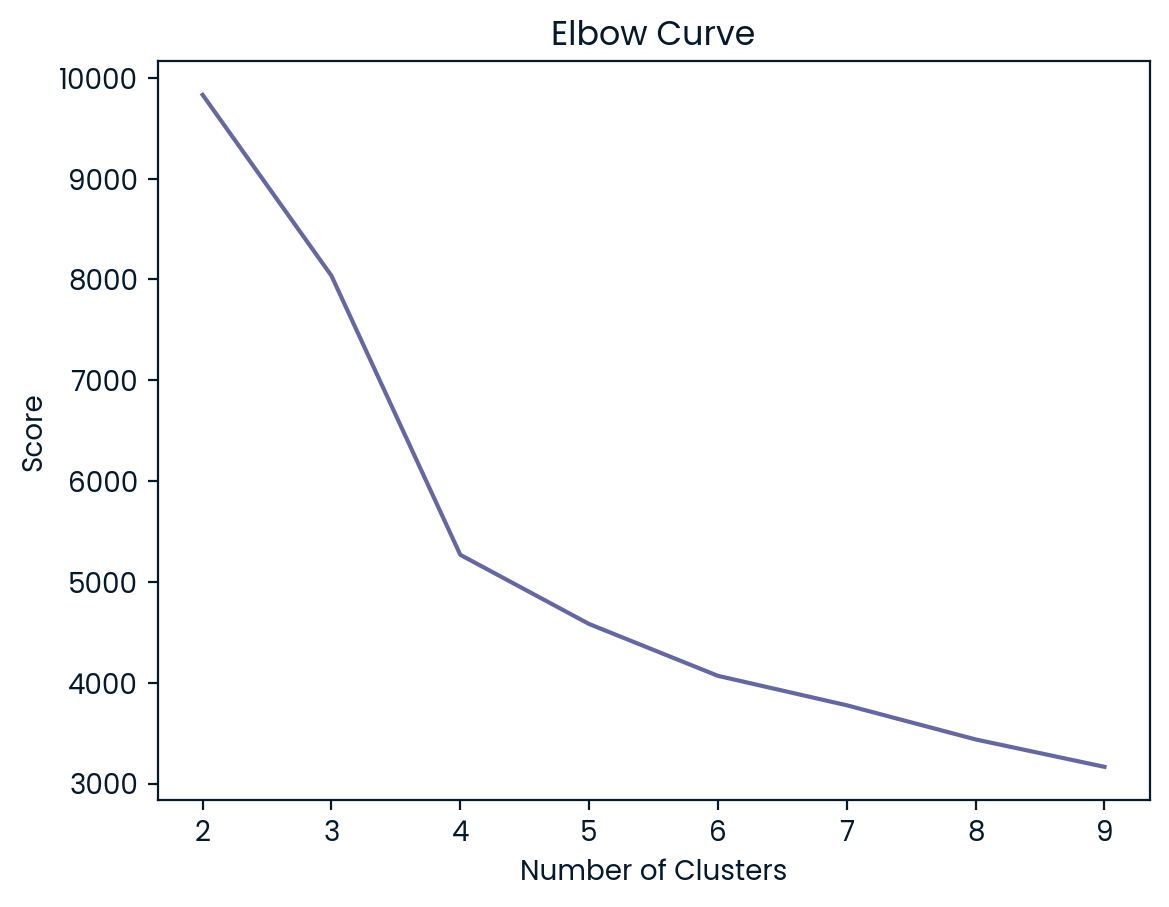

In [30]:
# Visualising the "Elbow Curve"

df_cost = pd.DataFrame(cost[2:])
df_cost.columns = ["cost"]
cluster_col = range(2,10)
df_cost.insert(0, "cluster", cluster_col)

plt.plot(df_cost.cluster, df_cost.cost)
plt.xlabel("Number of Clusters")
plt.ylabel("Score")
plt.title("Elbow Curve")
plt.show()

In [31]:
# From the plot above, we can see that there is an inflection point that looks like an elbow at 5. 

KMEANS_algo = KMeans(featuresCol="Standardized", k=5)
KMEANS_fit = KMEANS_algo.fit(scaled_data_final)

In [32]:
# Predictions

preds = KMEANS_fit.transform(scaled_data_final)
preds.show(5, 0)

+----------+--------+---------+------------------+------------------------------------+-----------------------------------------------------------+----------+
|CustomerID|Recency |Frequency|Monetary_Value    |Features                            |Standardized                                               |prediction|
+----------+--------+---------+------------------+------------------------------------+-----------------------------------------------------------+----------+
|15727     |59467200|32       |554.75            |[5.94672E7,32.0,554.75]             |[5.913894147027143,0.9580659875765422,1.1615513620728628]  |1         |
|17389     |53759340|17       |2714.4599999999996|[5.375934E7,17.0,2714.4599999999996]|[5.3462588817708285,0.508972555900038,5.683613718417851]   |0         |
|17389     |59469720|17       |2714.4599999999996|[5.946972E7,17.0,2714.4599999999996]|[5.914144755988899,0.508972555900038,5.683613718417851]    |0         |
|15447     |31633200|9        |155.17         

### **Cluster Analysis**

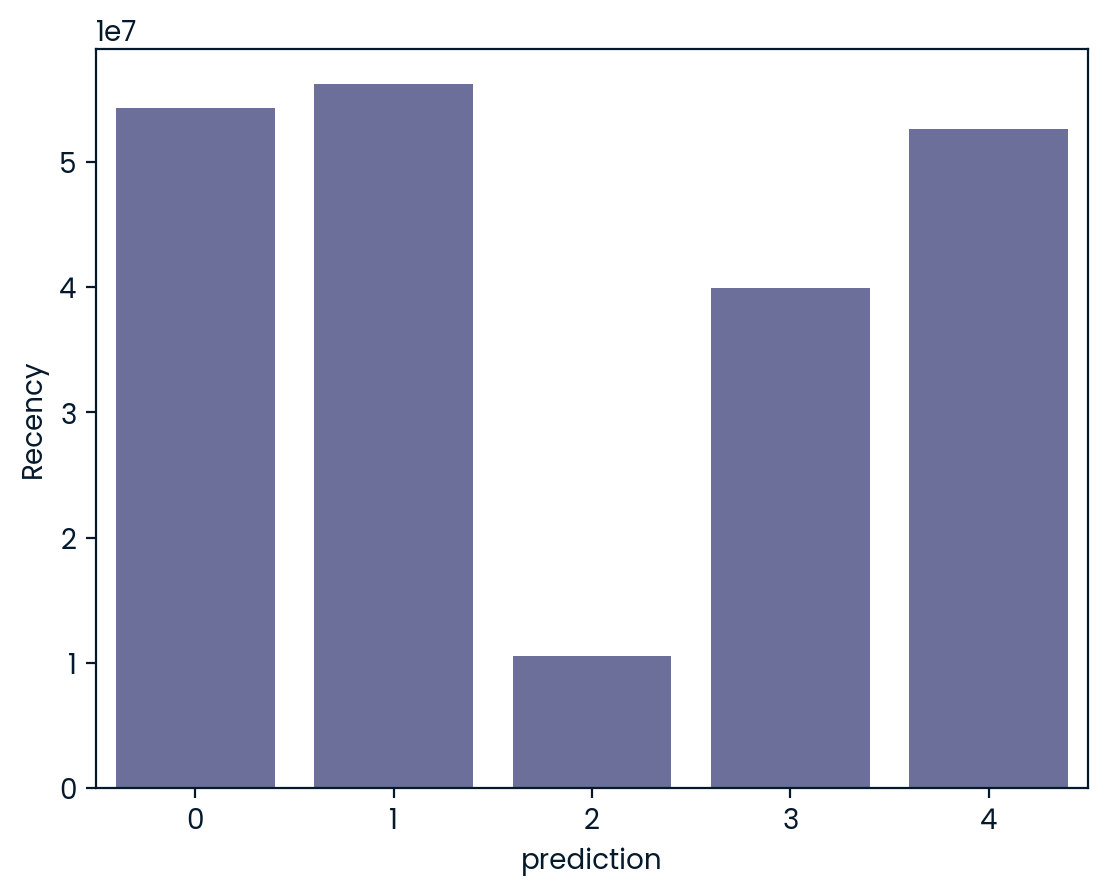

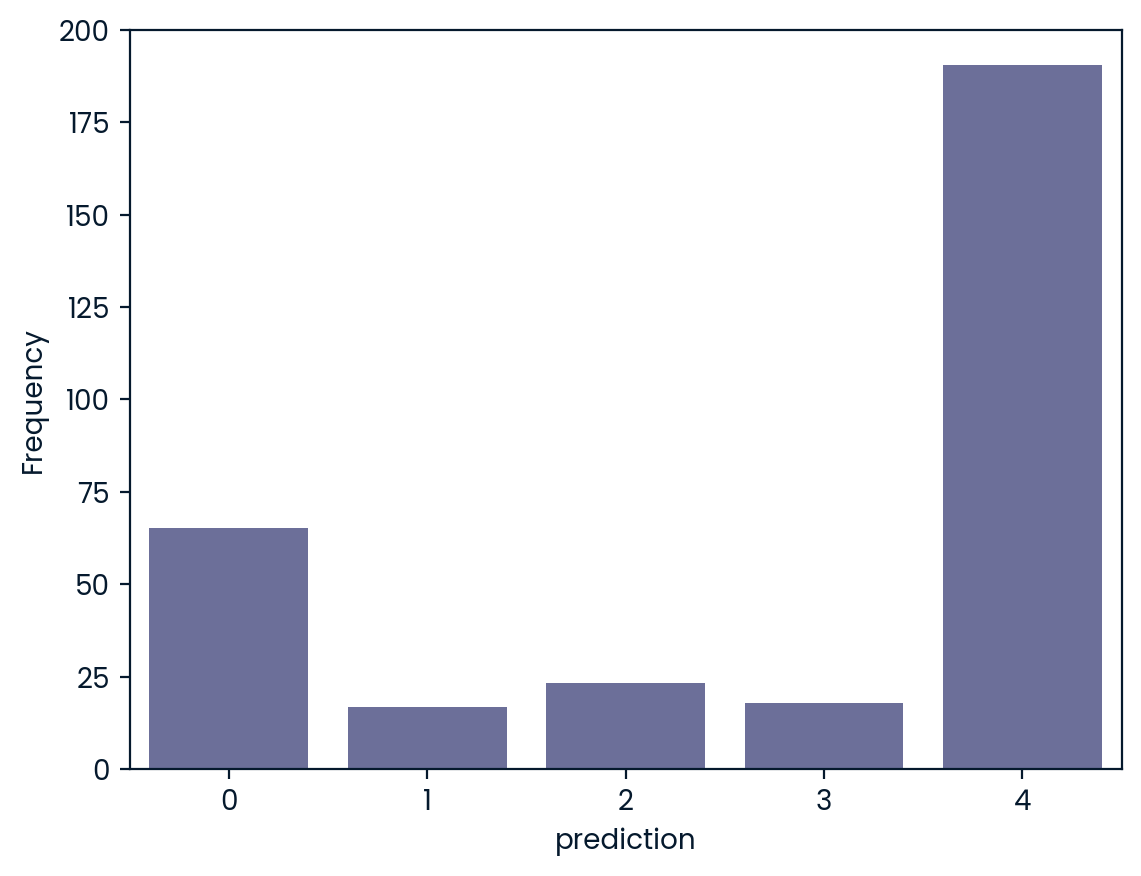

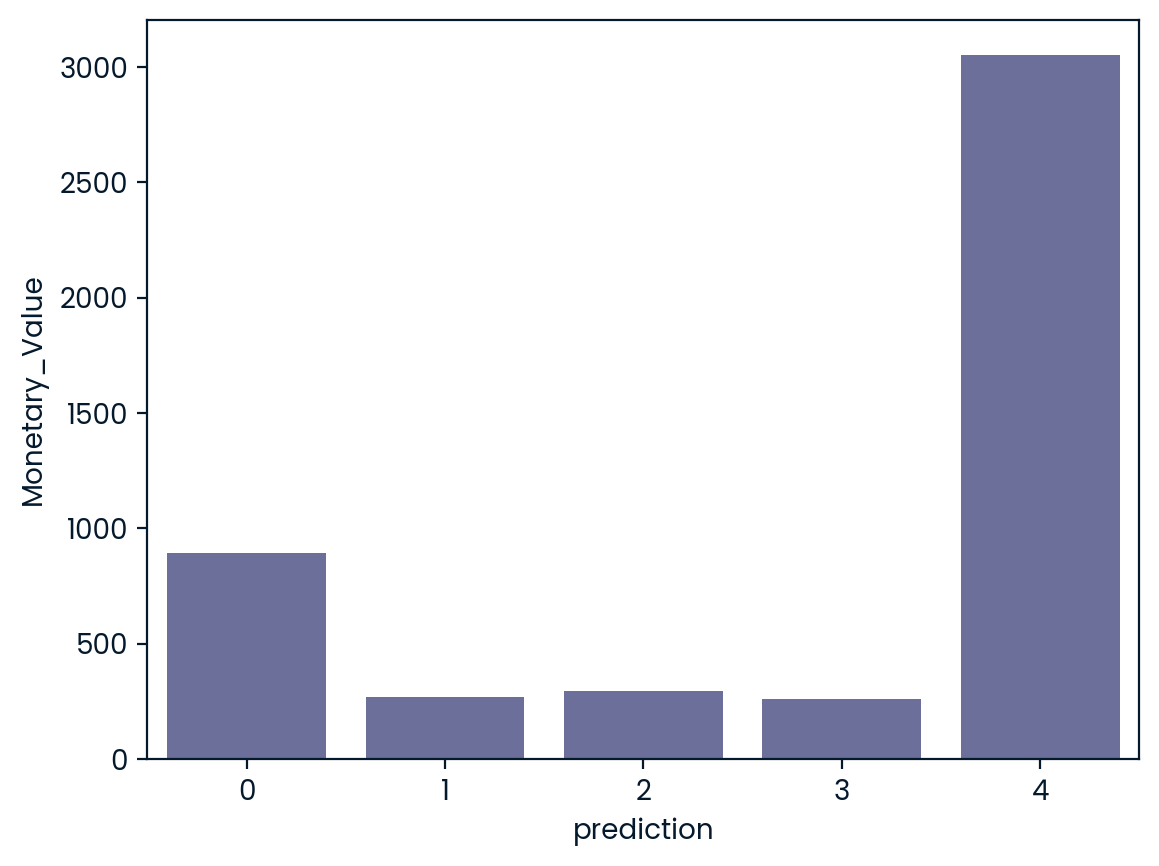

In [33]:
df_viz = preds.select("Recency", "Frequency", "Monetary_Value", "prediction")
df_viz_pandas = df_viz.toPandas()
avg_df_viz = df_viz_pandas.groupby(["prediction"], as_index=False).mean()

list_features = ["Recency", "Frequency", "Monetary_Value"]
for i in list_features:
    sns.barplot(
        x = "prediction",
        y = str(i),
        data = avg_df_viz
    )
    plt.show()